In [13]:
import pandas as pd
df_all = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")

df_all.dropna(inplace=True)
df_all

# pa


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_count_A,CDR_H1_count_R,CDR_H1_count_N,CDR_H1_count_D,CDR_H1_count_C,...,CDR_H2_mean_polarity,CDR_H2_mean_mass,CDR_H3_mean_hydrophobicity,CDR_H3_mean_charge,CDR_H3_mean_polarity,CDR_H3_mean_mass,cdr_h1_length,cdr_h2_length,cdr_h3_length,source
1,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9.0,5.0,8.0,human
2,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9.0,5.0,8.0,human
3,8znz,F,AIYYYGSSYNYYAMDY,SSGGGY,GFTFSKY,0.0,0.0,0.0,0.0,0.0,...,8.600000,102.763333,-0.506250,-0.062500,7.656250,142.335000,7.0,6.0,16.0,human
4,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7.0,6.0,8.0,human
5,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7.0,6.0,8.0,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,0.0,0.0,1.0,0.0,0.0,...,8.520000,108.302000,-0.855556,-0.222222,9.411111,131.915556,7.0,5.0,9.0,sars_cov2
1920,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,0.0,0.0,0.0,0.0,0.0,...,9.733333,123.780000,-0.250000,-0.166667,8.158333,129.798333,7.0,6.0,12.0,sars_cov2
1921,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,0.0,0.0,0.0,0.0,0.0,...,8.316667,105.945000,0.042857,-0.142857,8.214286,125.343571,7.0,6.0,14.0,sars_cov2
1922,7n3d,H,HSRIEVAGTLDFDY,YYSGN,GGSISSY,0.0,0.0,0.0,0.0,0.0,...,8.440000,134.932000,-0.307143,-0.071429,8.678571,132.637857,7.0,5.0,14.0,sars_cov2


In [14]:
import pandas as pd
import numpy as np
%pip install biopython
# Load the datasets from the specified paths
df_data = df_all

CDR_H3_sequences = df_data["CDR_H3"].tolist() # spalte CDR_H3 als liste
CDR_H2_sequences = df_data["CDR_H2"].tolist() # spalte CDR_H2 als liste
CDR_H1_sequences = df_data["CDR_H1"].tolist() # spalte CDR_H1 als liste
CDR=0 #
df_data.head()
extra_data_names = df_data.columns.tolist()[5:17] # spaltennamen als liste, ab so hydophobicity und so
extracted_data = df_data[extra_data_names].values.T # transformierte matrix, d.h. die einzelnen pdbs sind jetzt spalten, statt zeilen
print("Extracted data shape:", extracted_data.shape)
print("feature 1:", extra_data_names[0],extracted_data[0].shape)

for i,seq in enumerate(CDR_H3_sequences):
    if seq == "nan":
        print(i)
print("Number of CDR_H3 sequences with 'nan':", sum(seq == CDR_H2_sequences[0] for seq in CDR_H3_sequences))
print("Number of CDR_H2 sequences with 'nan':", sum(seq == "nan" for seq in CDR_H2_sequences))
print("Number of CDR_H1 sequences with 'nan':", sum(seq == "nan" for seq in CDR_H1_sequences))
for i,seq in enumerate(CDR_H2_sequences):
    if seq == "n":
        print(i)
print(CDR_H2_sequences[:10])

Note: you may need to restart the kernel to use updated packages.
Extracted data shape: (12, 1922)
feature 1: CDR_H1_count_A (1922,)
Number of CDR_H3 sequences with 'nan': 0
Number of CDR_H2 sequences with 'nan': 0
Number of CDR_H1 sequences with 'nan': 0
['FWDDD', 'FWDDD', 'SSGGGY', 'YPYYGS', 'YPYYGS', 'SYDGRH', 'IPVIDD', 'IPRLDA', 'NPNSGG', 'YWDHN']


In [15]:
print("CDR_H3 Sequences:", CDR_H3_sequences[:5])  # Print first 5 sequences

# Filter out non-string (e.g., NaN) entries
CDR_H3_sequences_clean = [seq for seq in CDR_H3_sequences if isinstance(seq, str)]
CDR_H2_sequences_clean = [seq for seq in CDR_H2_sequences if isinstance(seq, str)]
CDR_H1_sequences_clean = [seq for seq in CDR_H1_sequences if isinstance(seq, str)]

# max length of cdr sequences (for array)
max_length_h3 = max(len(seq) for seq in CDR_H3_sequences_clean)
max_length_h2 = max(len(seq) for seq in CDR_H2_sequences_clean)
max_length_h1 = max(len(seq) for seq in CDR_H1_sequences_clean)

print("Max length of CDR_H3 sequences:", max_length_h3) #cdrh3 haben die längsten cdr sequenzen
print("number of CDR_H3 sequences:", len(CDR_H3_sequences_clean))
print("number OF CDR_H2 sequences:", len(CDR_H2_sequences_clean))
print("number of CDR_H1 sequences:", len(CDR_H1_sequences_clean))

CDR_H3 Sequences: ['RFVGTLDV', 'RFVGTLDV', 'AIYYYGSSYNYYAMDY', 'GYGWALDY', 'GYGWALDY']
Max length of CDR_H3 sequences: 26
number of CDR_H3 sequences: 1922
number OF CDR_H2 sequences: 1922
number of CDR_H1 sequences: 1922


In [17]:
# feature matrix um sequenzen einheitlich als vektoren darzustellen
import numpy as np

# Function um eine sequnece in eine numerische Darstellung umzuwandeln
def onehot_of_sequence(seq, aa_list,length:int = None):
    if length is None:
        length = len(seq)
    aa_to_idx = {aa: i for i, aa in enumerate(aa_list)} # erzeugt dictionary
    onehot = np.zeros((length, len(aa_list)), dtype=int) # erzeugt matrix mit nullen (26x21)
    for i, aa in enumerate(seq): # für jede AS in der sequenz, wird an der passenden stelle eine 1 gesetzt
        idx = aa_to_idx.get(aa, aa_to_idx["-"])  # Handle unknown amino acids
        onehot[i, idx] = 1
    onehot = onehot.flatten()  # verwandelt matrix in vektor
    return onehot

#beispiel
example_embedding = onehot_of_sequence("CASSLGTGQYF", "ACDEFGHIKLMNPQRSTVWY-",length=1000) 
print("onehot_of_sequence:", example_embedding, "shape:", example_embedding.shape)

onehot_of_sequence: [0 1 0 ... 0 0 0] shape: (21000,)


In [18]:
def embedding_of_CDRs(CDRs=["H3"], aa_list = "ACDEFGHIKLMNPQRSTVWY-"): # definiere eine funktion, die
    #load the dataframe
    df_data = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")
    n_data = len(df_data[f"CDR_{CDRs[0]}"].tolist()) # Anzahl der Sequenzen in CDR_H3
    embedding = np.zeros((n_data, 1),dtype=float) #leeres numpy array als "Platzhalter"
    for CDR in CDRs:
        CDR_sequences = df_data[f"CDR_{CDR}"].tolist()
        max_length_h1 = max(len(seq) for seq in CDR_sequences)
        n_features = len(aa_list) * max_length_h1
        onehot = np.zeros((n_data, n_features), dtype=int)
        for i in range(len(CDR_sequences)):
            seq = CDR_sequences[i]
            seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h1)
            onehot[i, :] = seq_onehot
        print("onehot shape:", onehot.shape)
        embedding = np.concatenate((embedding, onehot), axis=1)
        
        #add the extracted data
        extra_data_names = df_data.columns.tolist()[5:17]
        
        #filter the extracted data for the current CDR
        for extra_data_name in extra_data_names:
            if CDR in extra_data_name:
                extracted_data = df_data[extra_data_name].values.reshape(-1, 1)  # Reshape to (n_data, 1)
                print(f"Extracted data for {extra_data_name} shape:", extracted_data.shape)
                embedding = np.concatenate((embedding, extracted_data), axis=1)
    print("embedding shape:", embedding.shape)
    # Exclude the first row which is all zeros
    embedding = embedding[:, 1:]  # Exclude the first row which is all zeros
    print("Final embedding shape:", embedding.shape)
    return embedding  # Exclude the first row which is all zeros



In [19]:
embedding=embedding_of_CDRs(["H3","H2","H1"])

TypeError: object of type 'float' has no len()

C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


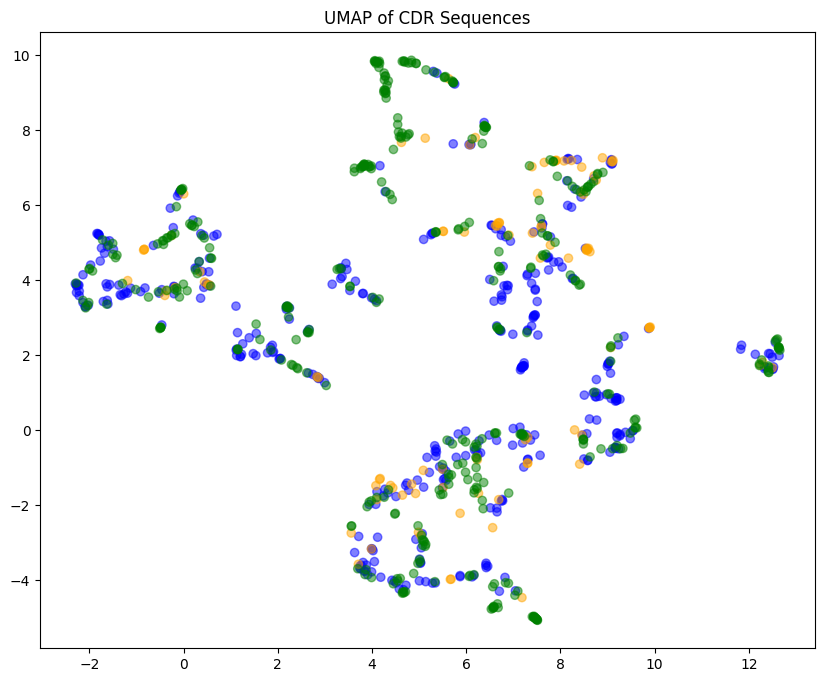

In [ ]:
import umap.umap_ as umap  # UMAP import
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(embedding)
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=color)
plt.title("UMAP of CDR Sequences")
plt.show()

Text(0.5, 1.0, 'KMeans Clustering of CDR Sequences')

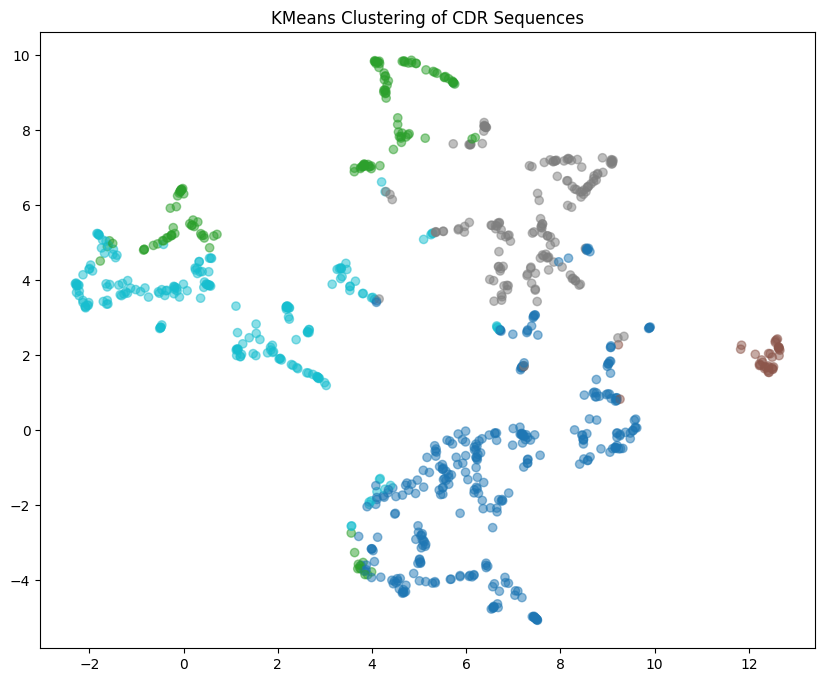

In [ ]:
#crate a kmeans clustering model
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(embedding)
# Predict the cluster labels
cluster_labels = kmeans.predict(embedding)

plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=cluster_labels, cmap='tab10')
plt.title("KMeans Clustering of CDR Sequences") 

In [ ]:
# train a logistic regression model
from sklearn.linear_model import LogisticRegression
embedding = embedding_of_CDRs(["H3","H2","H1"])
#shuffle the data
indexes = np.arange(embedding.shape[0])
np.random.seed(100)
np.random.shuffle(indexes)
embedding = embedding[indexes]
labels = df_nm["source"].values[indexes]
model = LogisticRegression(max_iter=int(1e4))  # Set a high max_iter to ensure convergence

# Fit the model to the data
model.fit(embedding[:750], labels[:750])
# evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(embedding[750:])


onehot shape: (857, 546)
Extracted data for CDR_H3_mean_hydrophobicity shape: (857, 1)
Extracted data for CDR_H3_mean_charge shape: (857, 1)
Extracted data for CDR_H3_mean_polarity shape: (857, 1)
Extracted data for CDR_H3_mean_mass shape: (857, 1)
onehot shape: (857, 210)
Extracted data for CDR_H2_mean_hydrophobicity shape: (857, 1)
Extracted data for CDR_H2_mean_charge shape: (857, 1)
Extracted data for CDR_H2_mean_polarity shape: (857, 1)
Extracted data for CDR_H2_mean_mass shape: (857, 1)
onehot shape: (857, 252)
Extracted data for CDR_H1_mean_hydrophobicity shape: (857, 1)
Extracted data for CDR_H1_mean_charge shape: (857, 1)
Extracted data for CDR_H1_mean_polarity shape: (857, 1)
Extracted data for CDR_H1_mean_mass shape: (857, 1)
embedding shape: (857, 1021)
Final embedding shape: (857, 1020)


Classification Report:
               precision    recall  f1-score   support

       human       0.82      0.80      0.81        50
   influenza       0.91      0.71      0.80        14
   sars_cov2       0.79      0.86      0.82        43

    accuracy                           0.81       107
   macro avg       0.84      0.79      0.81       107
weighted avg       0.82      0.81      0.81       107

Accuracy of the logistic regression model: 0.8130841121495327


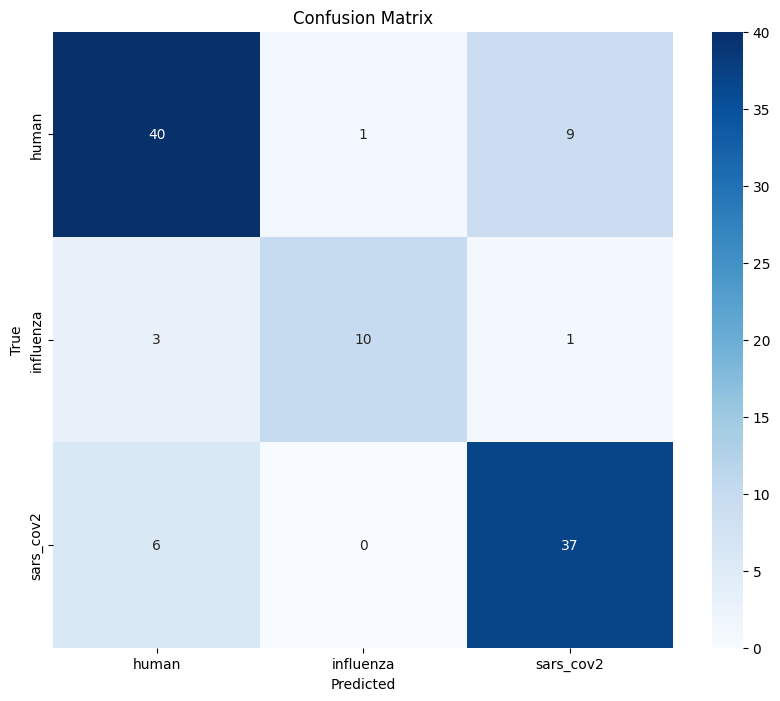

In [ ]:
y_true = labels[750:]
print("Classification Report:\n", classification_report(y_true, y_pred))
print("Accuracy of the logistic regression model:", accuracy_score(y_true, y_pred))

#plot the confusion matrix
import seaborn as sns
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=df_nm["source"].unique(), yticklabels=df_nm["source"].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# loop over all sequences and create the feature matrix
aa_list = "ACDEFGHIKLMNPQRSTVWY-"
n_features = len(aa_list) * (max_length_h3+ max_length_h2 + max_length_h1)

n_data = len(CDR_H3_sequences)
onehot = np.zeros((n_data, n_features), dtype=float)
for i in range(len(CDR_H3_sequences)):
    seq = CDR_H3_sequences[i]+ CDR_H1_sequences[i] + CDR_H2_sequences[i]
    seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h3+ max_length_h2 + max_length_h1)
    onehot[i, :] = seq_onehot
print("onehot shape:", onehot.shape)


onehot shape: (857, 1008)


In [ ]:
#concatenate the onehot encoding with the extracted data
onehot = np.concatenate((onehot, extracted_data.T), axis=1)
print("onehot shape after concatenation:", onehot.shape)

onehot shape after concatenation: (857, 1020)


In [ ]:
#add the other data points to the onehot encoding

In [ ]:
# do a PCA on the onehot encoding
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embedding)


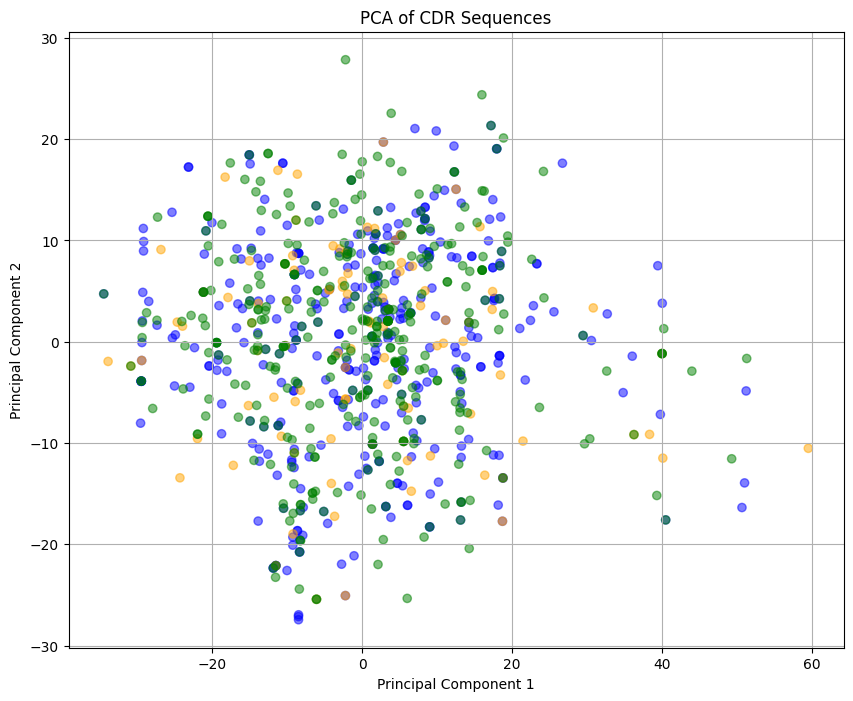

In [ ]:
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5,c=color)
plt.title("PCA of CDR Sequences")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

In [ ]:
n_features = len(aa_list) * (max_length_h3)#+ max_length_h2 + max_length_h1)

n_data = len(CDR_H3_sequences)
onehot = np.zeros((n_data, n_features), dtype=int)
for i in range(len(CDR_H3_sequences)):
    seq = CDR_H3_sequences[i]#+ CDR_H1_sequences[i] + CDR_H2_sequences[i]
    seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h3)#+ max_length_h2 + max_length_h1)
    onehot[i, :] = seq_onehot
print("onehot shape:", onehot.shape)

onehot shape: (857, 546)


In [ ]:
# do a PCA on the onehot encoding
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(onehot)


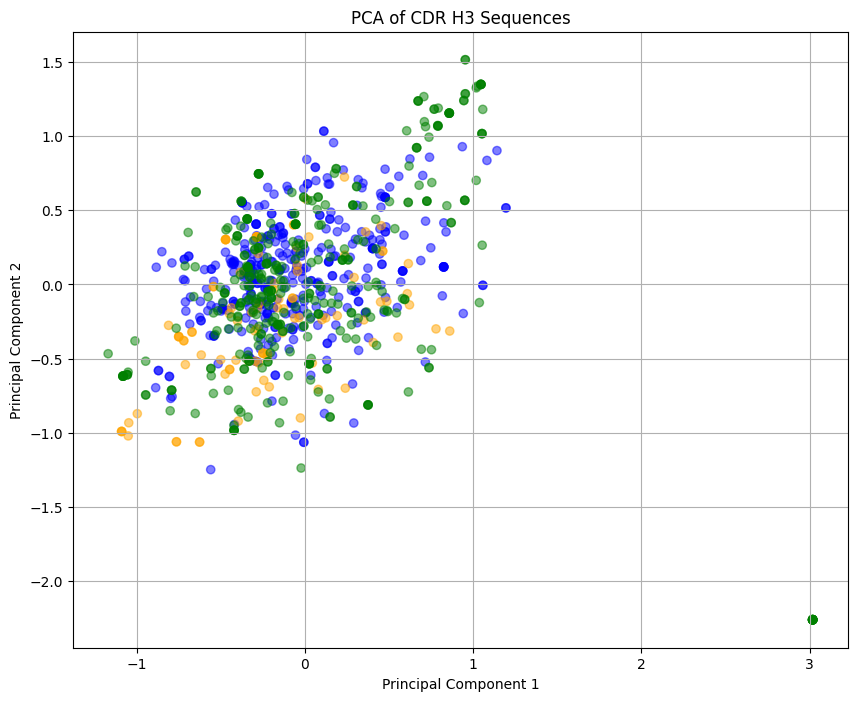

In [ ]:
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5,c=color)
plt.title("PCA of CDR H3 Sequences")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


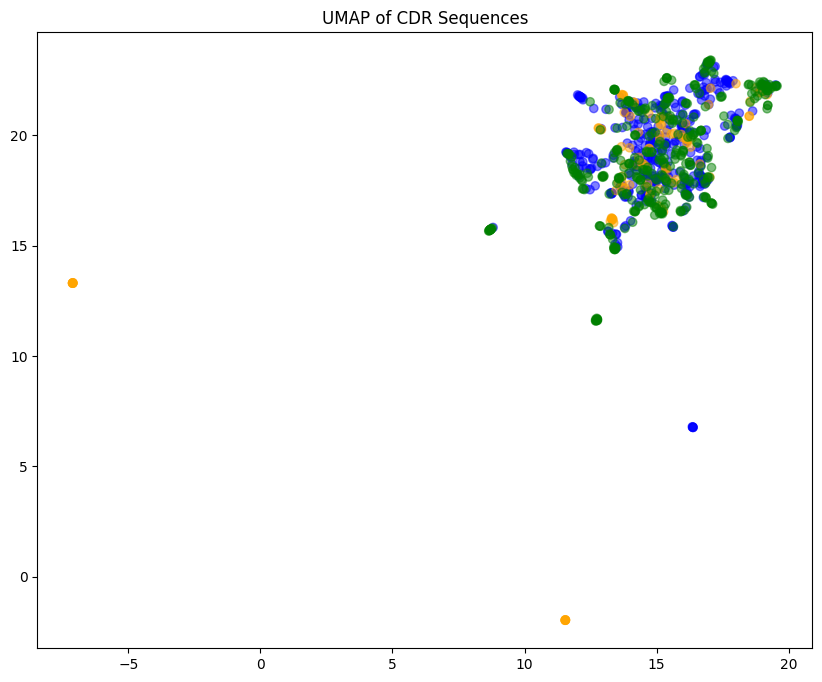

In [ ]:
import umap.umap_ as umap  # UMAP import
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(onehot)
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=color)
plt.title("UMAP of CDR Sequences")
plt.show()